# Colorectal Cancer Histopathological Image Classification: A Comparative Study of Traditional Machine Learning and Deep Learning Approaches

**Author:** Elvin Cyubahiro  
**Course:** Introduction to Machine Learning  
**Date:** June 2026

---

## 1. Introduction

Colorectal cancer is the third most commonly diagnosed cancer worldwide and the second leading cause of cancer-related deaths. Early and accurate identification of malignant tissue from histopathological images is critical for timely diagnosis and treatment planning. Manual examination by pathologists is time-consuming and subject to inter-observer variability, making automated classification systems a valuable clinical tool.

This project implements a complete machine learning pipeline comparing traditional ML approaches (Scikit-learn) with deep learning approaches (TensorFlow) for classifying colorectal tissue histopathological images as either adenocarcinoma epithelium (malignant) or normal colon mucosa (benign). The pipeline explores handcrafted feature extraction for classical models, convolutional neural networks built from scratch, and transfer learning with pretrained architectures, across 7 systematically designed experiments.

**Objectives:**
- Extract meaningful features from histopathological images for traditional ML classification (SVM, Random Forest)
- Build CNN architectures from scratch using TensorFlow's Sequential and Functional APIs
- Apply transfer learning with ResNet50 and MobileNetV2 pretrained on ImageNet
- Implement efficient image pipelines using TensorFlow's tf.data API
- Conduct systematic experiments with clear progression and critical analysis of results


## 2. Environment Setup & Library Imports

In [1]:
# Install dependencies
!pip install kagglehub -q

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Image processing
from PIL import Image
from skimage.feature import graycomatrix, graycoprops
from skimage.color import rgb2gray
from skimage import img_as_ubyte

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"NumPy: {np.__version__}")
print(f"TensorFlow: {tf.__version__}")
print(f"Scikit-learn: {__import__('sklearn').__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")


NumPy: 2.0.2
TensorFlow: 2.20.0
Scikit-learn: 1.6.1
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Data Loading

The dataset is the **NCT-CRC-HE-100K** colorectal histopathology dataset from Kather et al., a widely used benchmark in computational pathology. The images are real H&E-stained tissue patches manually extracted from 86 whole-slide images from the NCT Biobank (Heidelberg) and UMM pathology archive (Mannheim), at 224×224 pixels and 0.5 microns per pixel.

For this binary classification task we use two of the nine tissue classes:

- **TUM**: Colorectal adenocarcinoma epithelium (malignant) — labeled 1
- **NORM**: Normal colon mucosa (benign) — labeled 0

Unlike augmentation-generated datasets, these patches are independently extracted from real tissue slides, providing genuine biological variability across samples.

**Dataset source:** https://www.kaggle.com/datasets/gpreda/nct-crc-he-100k-subset  
**Original article:** J. N. Kather, N. Halama, and A. Marx, "100,000 histological images of human colorectal cancer and healthy tissue," Zenodo, 2018.


In [2]:
import kagglehub
import os

# 1. Download the dataset
dataset_path = kagglehub.dataset_download("gpreda/nct-crc-he-100k-subset")
print(f"Dataset downloaded to: {dataset_path}\n")

# 2. Extract files based on filename prefixes
# The subset stores class in the FILENAME (e.g. TUM_xxx.jpg, NORM_xxx.jpg)
# inside train/valid folders.
img_exts = ('.tif', '.tiff', '.png', '.jpg', '.jpeg')
aca_files = []      # TUM = adenocarcinoma (cancer)
normal_files = []   # NORM = benign

for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.lower().endswith(img_exts):
            full_path = os.path.join(root, f)
            name_upper = f.upper()
            if name_upper.startswith('TUM'):
                aca_files.append(full_path)
            elif name_upper.startswith('NORM'):
                normal_files.append(full_path)

# 3. Summary and Safety Check
print(f"Adenocarcinoma (TUM) images found: {len(aca_files)}")
print(f"Benign (NORM) images found:         {len(normal_files)}")
print(f"Total images collected:             {len(aca_files) + len(normal_files)}")

assert len(aca_files) > 0 and len(normal_files) > 0, "Lists are still empty. Please verify the filename prefixes in the dataset."

100%|██████████| 47.1M/47.1M [00:00<00:00, 94.0MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/gpreda/nct-crc-he-100k-subset/versions/1

Adenocarcinoma (TUM) images found: 1100
Benign (NORM) images found:         1100
Total images collected:             2200


## 4. Exploratory Data Analysis

Before any modeling, we examine the dataset to understand image properties, class distribution, and visual characteristics that might influence model design.


### 4.1 Class Distribution

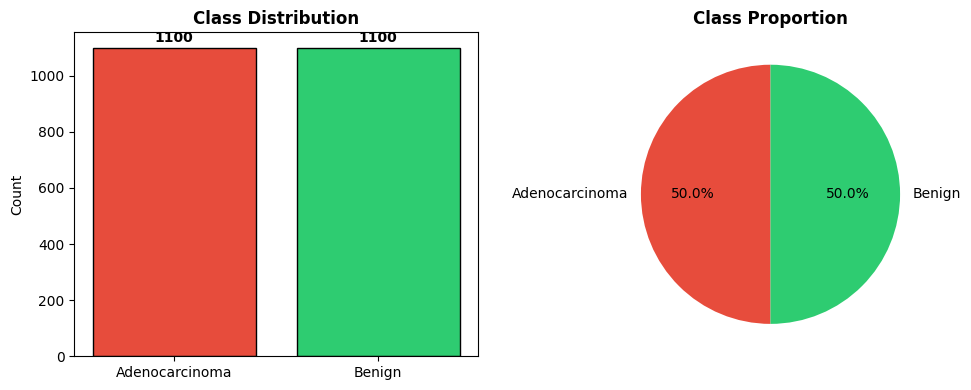

Class ratio: 1.00:1 — Perfectly balanced


In [3]:
import matplotlib.pyplot as plt

# Recalculate class distribution from the now-populated file lists
class_counts = {'Adenocarcinoma': len(aca_files), 'Benign': len(normal_files)}

if sum(class_counts.values()) == 0:
    print("Error: Lists are still empty. Please re-run the data loading cell (cfbae4b6).")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    # Bar Chart
    axes[0].bar(class_counts.keys(), class_counts.values(), color=['#e74c3c', '#2ecc71'], edgecolor='black')
    axes[0].set_title('Class Distribution', fontweight='bold')
    axes[0].set_ylabel('Count')
    for i, (k, v) in enumerate(class_counts.items()):
        axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

    # Pie Chart
    axes[1].pie(class_counts.values(), labels=class_counts.keys(), autopct='%1.1f%%',
                colors=['#e74c3c', '#2ecc71'], startangle=90)
    axes[1].set_title('Class Proportion', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"Class ratio: {class_counts['Adenocarcinoma']/class_counts['Benign']:.2f}:1 — Perfectly balanced")

### 4.2 Sample Images

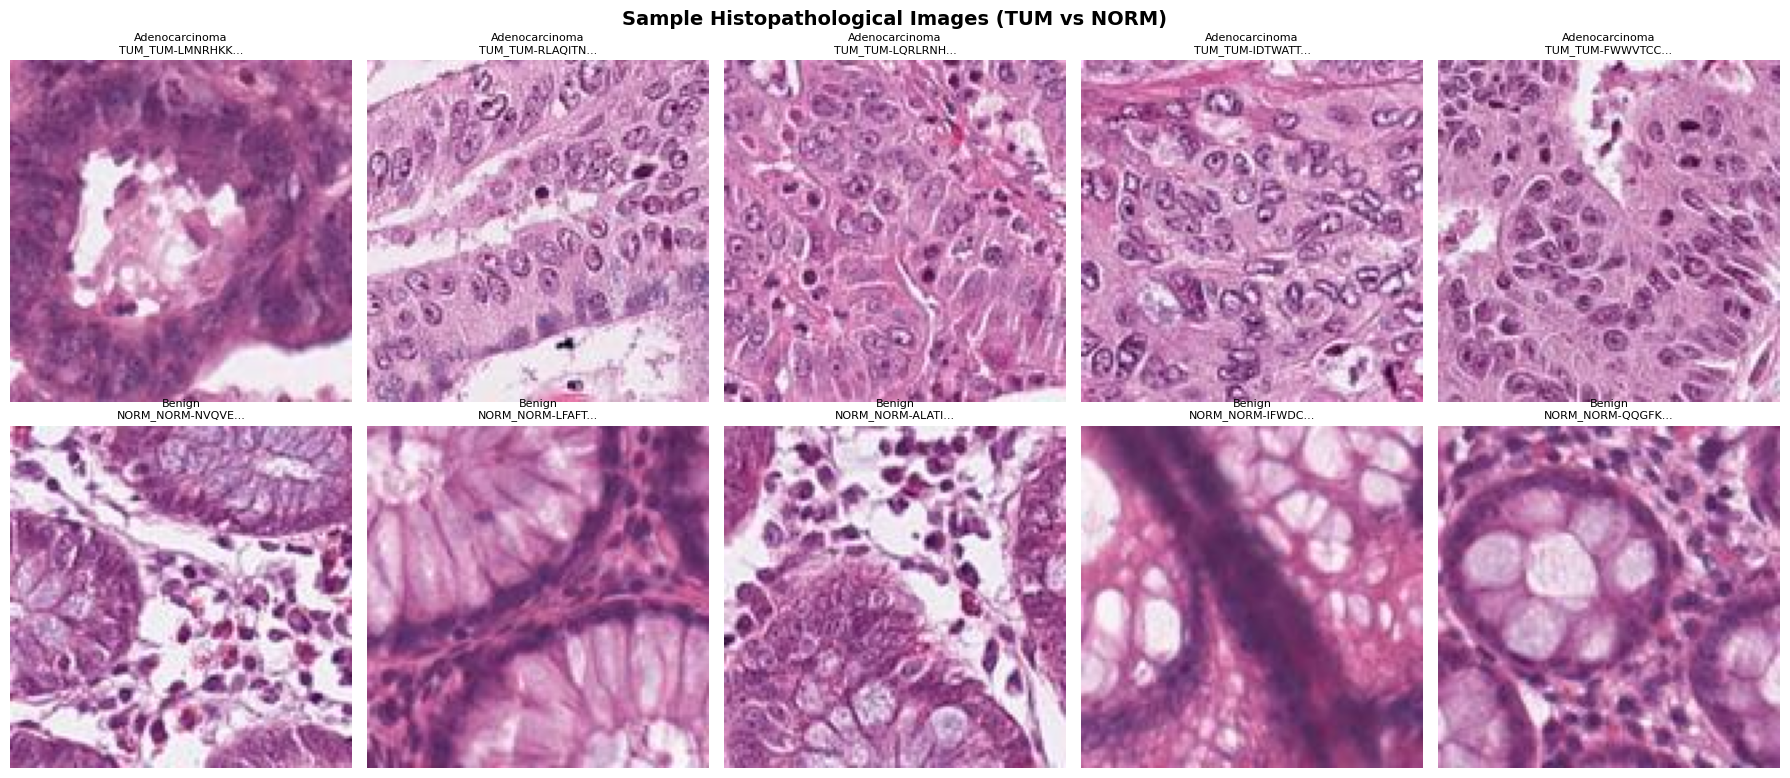

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

# Refresh lists to ensure we are using the latest loaded data
# Display sample images from each class
if len(aca_files) >= 5 and len(normal_files) >= 5:
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))

    for i in range(5):
        # Adenocarcinoma samples
        img = Image.open(aca_files[i])
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'Adenocarcinoma\n{os.path.basename(aca_files[i])[:15]}...', fontsize=8)
        axes[0, i].axis('off')

        # Benign samples
        img = Image.open(normal_files[i])
        axes[1, i].imshow(img)
        axes[1, i].set_title(f'Benign\n{os.path.basename(normal_files[i])[:15]}...', fontsize=8)
        axes[1, i].axis('off')

    plt.suptitle('Sample Histopathological Images (TUM vs NORM)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"Warning: Still only found {len(aca_files)} aca and {len(normal_files)} normal files. Please re-run cell cfbae4b6 first.")

### 4.3 Image Properties

In [5]:
# Check image dimensions and properties
sample_img = Image.open(aca_files[0])
print(f"Image size: {sample_img.size}")
print(f"Image mode: {sample_img.mode}")

# Check if all images are same size
sizes = set()
for f in aca_files[:100] + normal_files[:100]:
    sizes.add(Image.open(f).size)
print(f"Unique sizes found (sample of 200): {sizes}")


Image size: (128, 128)
Image mode: RGB
Unique sizes found (sample of 200): {(128, 128)}


### 4.4 Color Distribution Analysis

Histopathological images stained with H&E (Hematoxylin and Eosin) have characteristic color profiles. Examining the RGB channel distributions for each class may reveal patterns that handcrafted features can capture.


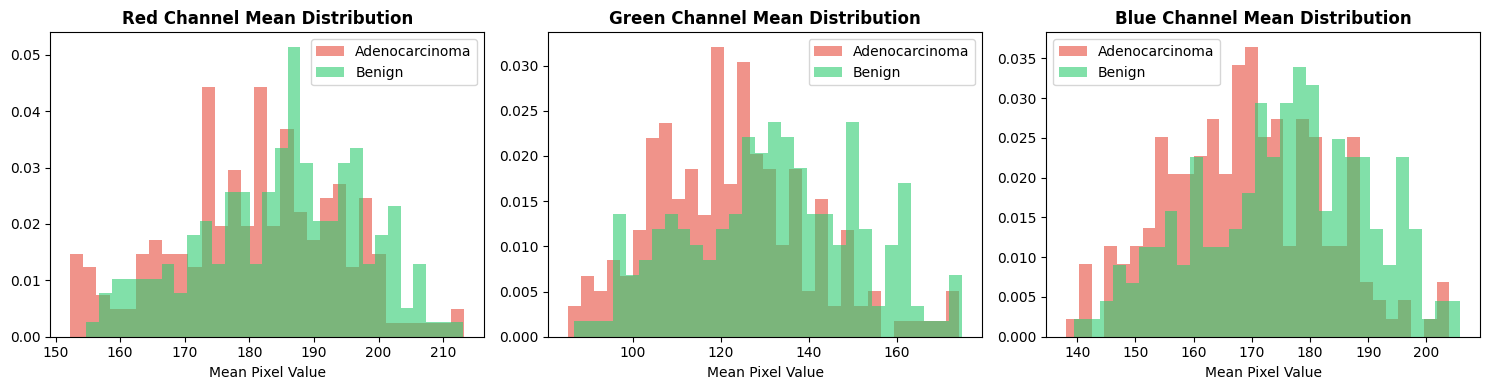

In [6]:
# RGB channel distributions by class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channels = ['Red', 'Green', 'Blue']
colors = ['#e74c3c', '#2ecc71', '#3498db']

# Sample 200 images per class for efficiency
sample_size = 200
aca_means = {c: [] for c in range(3)}
normal_means = {c: [] for c in range(3)}

for f in aca_files[:sample_size]:
    img = np.array(Image.open(f))
    for c in range(3):
        aca_means[c].append(img[:,:,c].mean())

for f in normal_files[:sample_size]:
    img = np.array(Image.open(f))
    for c in range(3):
        normal_means[c].append(img[:,:,c].mean())

for i, (ch_name, color) in enumerate(zip(channels, colors)):
    axes[i].hist(aca_means[i], bins=30, alpha=0.6, color='#e74c3c', label='Adenocarcinoma', density=True)
    axes[i].hist(normal_means[i], bins=30, alpha=0.6, color='#2ecc71', label='Benign', density=True)
    axes[i].set_title(f'{ch_name} Channel Mean Distribution', fontweight='bold')
    axes[i].set_xlabel('Mean Pixel Value')
    axes[i].legend()

plt.tight_layout()
plt.show()


## 5. Data Preprocessing

### 5.1 Image Loading & Resizing

All images are resized to 224×224 pixels — the standard input size for pretrained models (ResNet50, MobileNetV2). Labels are encoded as 1 (adenocarcinoma) and 0 (benign).


In [7]:
# Image parameters
IMG_SIZE = 224
BATCH_SIZE = 32

# Build file paths and labels
all_files = aca_files + normal_files
all_labels = [1] * len(aca_files) + [0] * len(normal_files)  # 1 = cancer, 0 = benign

print(f"Total samples: {len(all_files)}")
print(f"Label distribution: {np.bincount(all_labels)} [benign, cancer]")

# Split: 70% train, 15% val, 15% test (stratified)
X_train_files, X_test_files, y_train, y_test = train_test_split(
    all_files, all_labels, test_size=0.15, random_state=SEED, stratify=all_labels
)
X_train_files, X_val_files, y_train, y_val = train_test_split(
    X_train_files, y_train, test_size=0.176, random_state=SEED, stratify=y_train
)

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

print(f"\nTrain: {len(X_train_files)} | Val: {len(X_val_files)} | Test: {len(X_test_files)}")
print(f"Train labels: {np.bincount(y_train)}")
print(f"Val labels:   {np.bincount(y_val)}")
print(f"Test labels:  {np.bincount(y_test)}")


Total samples: 2200
Label distribution: [1100 1100] [benign, cancer]

Train: 1540 | Val: 330 | Test: 330
Train labels: [770 770]
Val labels:   [165 165]
Test labels:  [165 165]


### 5.2 Feature Extraction for Traditional ML

Since traditional ML models (SVM, Random Forest) cannot process raw images directly, we extract handcrafted features that capture color, texture, and statistical properties of the tissue images:

- **Color statistics:** Mean, standard deviation, and skewness of each RGB channel (9 features)
- **Color histograms:** Binned pixel intensity distributions per channel (96 features)
- **Texture features (GLCM):** Contrast, dissimilarity, homogeneity, energy, and correlation from the Gray-Level Co-occurrence Matrix (5 features)

Total: 110 features per image


In [8]:
from scipy.stats import skew

def extract_features(file_path):
    """Extract handcrafted features from a histopathological image."""
    img = np.array(Image.open(file_path).resize((IMG_SIZE, IMG_SIZE)))

    features = []

    # 1. Color statistics per channel (mean, std, skewness) — 9 features
    for c in range(3):
        channel = img[:, :, c].flatten()
        features.extend([channel.mean(), channel.std(), skew(channel)])

    # 2. Color histograms per channel (32 bins each) — 96 features
    for c in range(3):
        hist, _ = np.histogram(img[:, :, c], bins=32, range=(0, 256))
        hist = hist / hist.sum()  # Normalize
        features.extend(hist)

    # 3. GLCM texture features — 5 features
    gray = img_as_ubyte(rgb2gray(img))
    # Quantize to 64 levels for manageable GLCM
    gray_quantized = (gray // 4).astype(np.uint8)
    glcm = graycomatrix(gray_quantized, distances=[1], angles=[0], levels=64, symmetric=True, normed=True)
    features.append(graycoprops(glcm, 'contrast')[0, 0])
    features.append(graycoprops(glcm, 'dissimilarity')[0, 0])
    features.append(graycoprops(glcm, 'homogeneity')[0, 0])
    features.append(graycoprops(glcm, 'energy')[0, 0])
    features.append(graycoprops(glcm, 'correlation')[0, 0])

    return np.array(features)

# Test on one image
sample_features = extract_features(aca_files[0])
print(f"Features per image: {len(sample_features)}")
print(f"Feature vector sample: {sample_features[:10].round(3)}")


Features per image: 110
Feature vector sample: [166.482  41.176   0.598 107.8    53.778   1.228 154.697  40.508   1.03
   0.   ]


In [9]:
# Extract features for all splits (this takes a few minutes)
from tqdm import tqdm

print("Extracting training features...")
X_train_feat = np.array([extract_features(f) for f in tqdm(X_train_files)])

print("Extracting validation features...")
X_val_feat = np.array([extract_features(f) for f in tqdm(X_val_files)])

print("Extracting test features...")
X_test_feat = np.array([extract_features(f) for f in tqdm(X_test_files)])

print(f"\nFeature shapes — Train: {X_train_feat.shape} | Val: {X_val_feat.shape} | Test: {X_test_feat.shape}")


Extracting training features...


100%|██████████| 1540/1540 [00:35<00:00, 42.95it/s]


Extracting validation features...


100%|██████████| 330/330 [00:04<00:00, 68.19it/s] 


Extracting test features...


100%|██████████| 330/330 [00:03<00:00, 106.44it/s]


Feature shapes — Train: (1540, 110) | Val: (330, 110) | Test: (330, 110)


### 5.3 Feature Scaling

Standardization ensures all features have zero mean and unit variance, which is critical for SVM (distance-based) and beneficial for Random Forest consistency. The scaler is fitted only on training data to prevent data leakage.


In [10]:
# Scale features (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled = scaler.transform(X_val_feat)
X_test_scaled = scaler.transform(X_test_feat)

print("Feature scaling complete.")
print(f"Train mean: {X_train_scaled.mean(axis=0)[:5].round(4)} ...")
print(f"Train std:  {X_train_scaled.std(axis=0)[:5].round(4)} ...")


Feature scaling complete.
Train mean: [ 0. -0.  0.  0.  0.] ...
Train std:  [1. 1. 1. 1. 1.] ...


## 6. Evaluation Helper Functions

Reusable functions for evaluation, visualization, and results tracking ensure consistency across all 7 experiments.


In [11]:
# ===== RESULTS TABLE =====
results = []

def log_result(experiment, model_name, approach, api, hyperparameters, y_true, y_pred, y_prob=None):
    """Log experiment results to the global results table."""
    metrics = {
        'Experiment': experiment,
        'Model': model_name,
        'Approach': approach,
        'API': api,
        'Hyperparameters': hyperparameters,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob) if y_prob is not None else None
    }
    results.append(metrics)

    print(f"\n{'='*55}")
    print(f"  {experiment}: {model_name}")
    print(f"  Approach: {approach} | API: {api}")
    print(f"{'='*55}")
    for k in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
        if metrics[k] is not None:
            print(f"  {k:>12}: {metrics[k]:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Benign', 'Adenocarcinoma'])}")
    return metrics


def plot_confusion_matrix(y_true, y_pred, title):
    """Plot confusion matrix with counts."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Adenocarcinoma'],
                yticklabels=['Benign', 'Adenocarcinoma'])
    plt.title(f'Confusion Matrix — {title}', fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    print(f"  True Neg: {tn} | False Pos: {fp} | False Neg: {fn} | True Pos: {tp}")
    print(f"  False Positive Rate: {fp/(fp+tn):.4f} (healthy tissue flagged as cancer)")
    print(f"  False Negative Rate: {fn/(fn+tp):.4f} (cancer missed as healthy)")


def plot_roc_curve(y_true, y_prob, title):
    """Plot ROC curve with AUC."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
    plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {title}', fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_dl_history(history, title):
    """Plot training/validation loss and accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'], label='Train Loss', color='#2ecc71')
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Loss Curve — {title}', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#e74c3c')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Accuracy Curve — {title}', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    gap = final_val_loss - final_train_loss
    print(f"  Final train loss: {final_train_loss:.4f} | Final val loss: {final_val_loss:.4f} | Gap: {gap:.4f}")

print("Helper functions defined.")


Helper functions defined.


## 7. Traditional Machine Learning Experiments (Scikit-learn)

These experiments use the handcrafted features extracted in Section 5.2. Traditional ML models cannot learn directly from raw pixels, so the quality of these features determines the performance ceiling for this approach.

---

### Experiment 1: Support Vector Machine (RBF Kernel)

SVM with an RBF kernel maps features into a higher-dimensional space to find non-linear decision boundaries. It is well-suited for binary classification with moderate feature counts. We use the full extracted feature set (110 features) with standardized scaling.

**Hyperparameters:** `C=10`, `kernel='rbf'`, `gamma='scale'`


EXPERIMENT 1: SVM (RBF Kernel)
--------------------------------------------------

  Exp1: SVM (RBF)
  Approach: Traditional ML | API: Scikit-learn
      Accuracy: 0.9394
     Precision: 0.9503
        Recall: 0.9273
      F1-Score: 0.9387
       ROC-AUC: 0.9863

                precision    recall  f1-score   support

        Benign       0.93      0.95      0.94       165
Adenocarcinoma       0.95      0.93      0.94       165

      accuracy                           0.94       330
     macro avg       0.94      0.94      0.94       330
  weighted avg       0.94      0.94      0.94       330



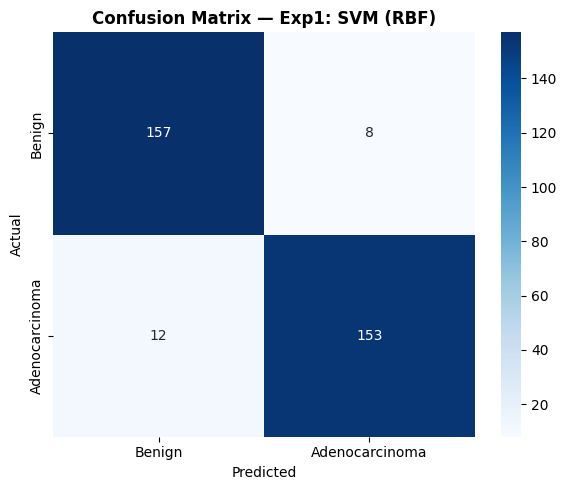

  True Neg: 157 | False Pos: 8 | False Neg: 12 | True Pos: 153
  False Positive Rate: 0.0485 (healthy tissue flagged as cancer)
  False Negative Rate: 0.0727 (cancer missed as healthy)


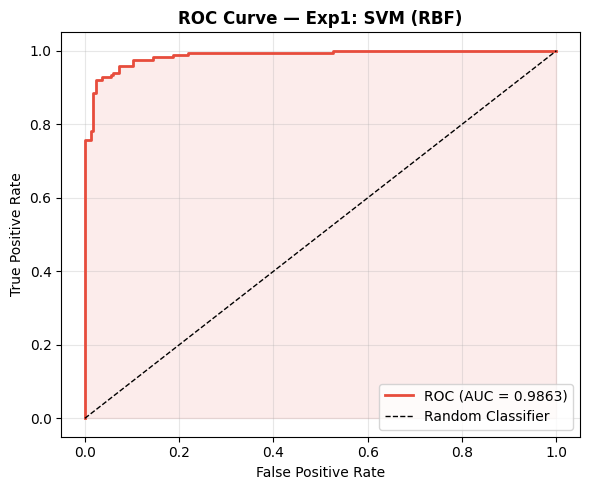

In [12]:
# Experiment 1: SVM
print("EXPERIMENT 1: SVM (RBF Kernel)")
print("-" * 50)

svm_model = SVC(C=10, kernel='rbf', gamma='scale', probability=True, random_state=SEED)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

log_result('Exp1', 'SVM (RBF)', 'Traditional ML', 'Scikit-learn',
           'C=10, kernel=rbf, gamma=scale', y_test, y_pred_svm, y_prob_svm)
plot_confusion_matrix(y_test, y_pred_svm, 'Exp1: SVM (RBF)')
plot_roc_curve(y_test, y_prob_svm, 'Exp1: SVM (RBF)')


### Experiment 1 — Observations

SVM achieved 93.94% accuracy and 93.87% F1 on the 110 handcrafted features, with only 12 false negatives and 8 false positives out of 330 test images. ROC-AUC of 0.9863 confirms strong discriminative ability. This sets a high baseline for subsequent experiments.


EXPERIMENT 2: Random Forest
--------------------------------------------------

  Exp2: Random Forest
  Approach: Traditional ML | API: Scikit-learn
      Accuracy: 0.9091
     Precision: 0.8814
        Recall: 0.9455
      F1-Score: 0.9123
       ROC-AUC: 0.9709

                precision    recall  f1-score   support

        Benign       0.94      0.87      0.91       165
Adenocarcinoma       0.88      0.95      0.91       165

      accuracy                           0.91       330
     macro avg       0.91      0.91      0.91       330
  weighted avg       0.91      0.91      0.91       330



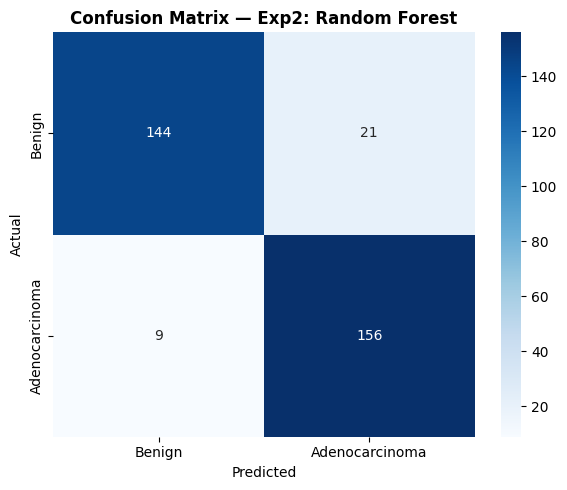

  True Neg: 144 | False Pos: 21 | False Neg: 9 | True Pos: 156
  False Positive Rate: 0.1273 (healthy tissue flagged as cancer)
  False Negative Rate: 0.0545 (cancer missed as healthy)


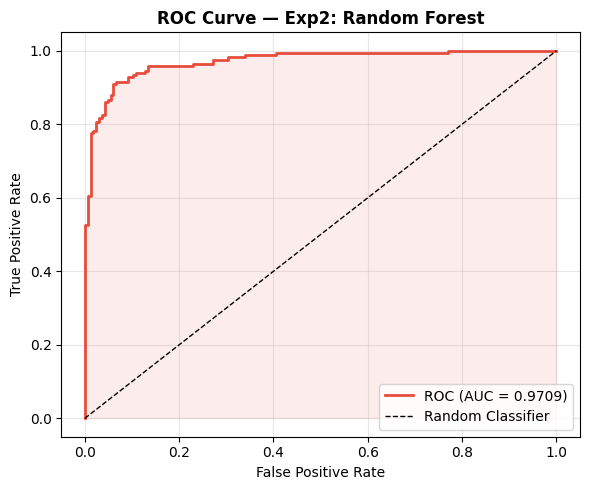

In [13]:
# Experiment 2: Random Forest
print("EXPERIMENT 2: Random Forest")
print("-" * 50)

rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=5,
    random_state=SEED, n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

log_result('Exp2', 'Random Forest', 'Traditional ML', 'Scikit-learn',
           'n_estimators=200, max_depth=20, min_samples_leaf=5',
           y_test, y_pred_rf, y_prob_rf)
plot_confusion_matrix(y_test, y_pred_rf, 'Exp2: Random Forest')
plot_roc_curve(y_test, y_prob_rf, 'Exp2: Random Forest')


### Feature Importance Analysis

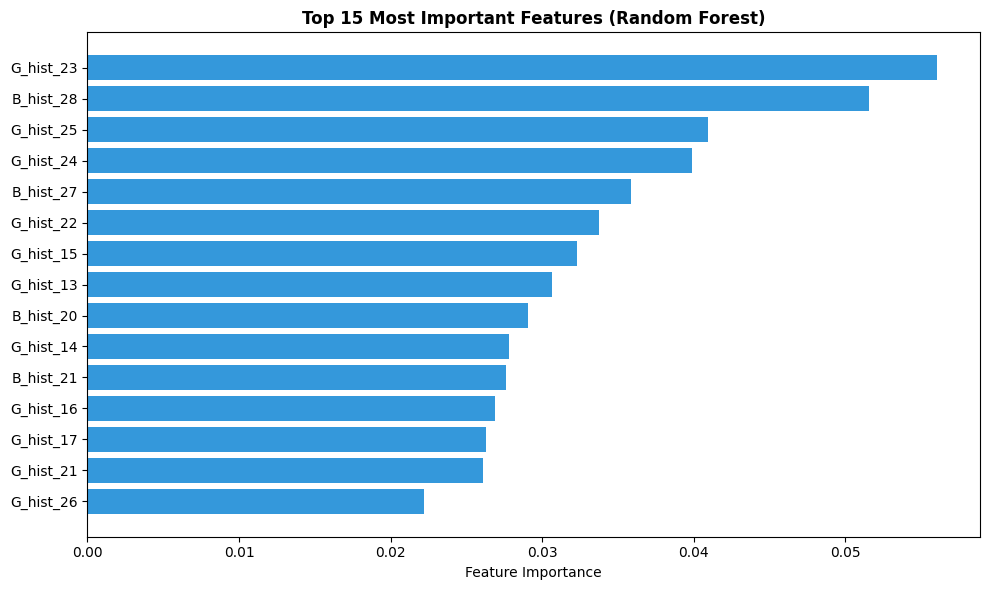


Top 10 features:
                  G_hist_23: 0.0561
                  B_hist_28: 0.0516
                  G_hist_25: 0.0409
                  G_hist_24: 0.0399
                  B_hist_27: 0.0359
                  G_hist_22: 0.0337
                  G_hist_15: 0.0323
                  G_hist_13: 0.0307
                  B_hist_20: 0.0291
                  G_hist_14: 0.0278


In [14]:
# Feature importance from Random Forest
# Build feature names
feat_names = []
for ch in ['R', 'G', 'B']:
    feat_names.extend([f'{ch}_mean', f'{ch}_std', f'{ch}_skew'])
for ch in ['R', 'G', 'B']:
    feat_names.extend([f'{ch}_hist_{i}' for i in range(32)])
feat_names.extend(['GLCM_contrast', 'GLCM_dissimilarity', 'GLCM_homogeneity', 'GLCM_energy', 'GLCM_correlation'])

importance_df = pd.DataFrame({
    'Feature': feat_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Top 15 features
plt.figure(figsize=(10, 6))
top15 = importance_df.head(15)
plt.barh(top15['Feature'][::-1], top15['Importance'][::-1], color='#3498db')
plt.xlabel('Feature Importance')
plt.title('Top 15 Most Important Features (Random Forest)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
for _, row in importance_df.head(10).iterrows():
    print(f"  {row['Feature']:>25}: {row['Importance']:.4f}")


### Experiment 2 — Observations

Random Forest scored 90.91% accuracy and 91.23% F1, approximately 2.6 points below SVM. It produced fewer false negatives (9 vs 12) but more false positives (21 vs 8) — a more aggressive classification style. Feature importance analysis showed color histogram bins from the green and blue channels as the most informative features, consistent with H&E staining properties.


## 8. tf.data Image Pipeline

The `tf.data` API provides optimized image loading with prefetching and parallel processing. We create pipelines for all deep learning experiments, resizing images to 224×224 and normalizing pixel values to [0, 1].


In [15]:
# tf.data pipeline for image loading
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(file_path, label):
    """Load, decode, resize, and normalize an image."""
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0  # Normalize to [0, 1]
    return img, label

def create_dataset(file_paths, labels, shuffle=False):
    """Create a tf.data dataset from file paths and labels."""
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_paths), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

# Create datasets
train_ds = create_dataset(X_train_files, y_train, shuffle=True)
val_ds = create_dataset(X_val_files, y_val)
test_ds = create_dataset(X_test_files, y_test)

# Verify
for batch_img, batch_lbl in train_ds.take(1):
    print(f"Image batch shape: {batch_img.shape}")
    print(f"Label batch shape: {batch_lbl.shape}")
    print(f"Pixel range: [{batch_img.numpy().min():.2f}, {batch_img.numpy().max():.2f}]")

print(f"\nTrain batches: {len(train_ds)} | Val batches: {len(val_ds)} | Test batches: {len(test_ds)}")


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: [0.00, 1.00]

Train batches: 49 | Val batches: 11 | Test batches: 11


In [16]:
# Shared training config
EPOCHS = 30

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

print(f"Max epochs: {EPOCHS}")
print("Callbacks: EarlyStopping (patience=7), ReduceLROnPlateau (patience=3)")


Max epochs: 30
Callbacks: EarlyStopping (patience=7), ReduceLROnPlateau (patience=3)


## 9. Deep Learning from Scratch — Sequential API

### Experiment 3: Simple CNN (Sequential API)

Our first CNN uses a straightforward convolutional architecture built with the Sequential API. This establishes a deep learning baseline using learned features rather than handcrafted ones.

**Architecture:** Conv2D(32) → MaxPool → Conv2D(64) → MaxPool → Conv2D(128) → MaxPool → Flatten → Dense(128) → Dense(1)  
**Optimizer:** Adam (lr=0.001)


EXPERIMENT 3: Simple CNN — Sequential API
--------------------------------------------------


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,561 (49.36 MB)

 Trainable params: 12,938,561 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 152ms/step - accuracy: 0.5143 - loss: 0.8868 - val_accuracy: 0.5000 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5104 - loss: 0.6900 - val_accuracy: 0.5000 - val_loss: 0.6877 - learning_rate: 0.0010
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.5766 - loss: 0.6776 - val_accuracy: 0.6758 - val_loss: 0.6270 - learning_rate: 0.0010
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.4812 - loss: 0.6949 - val_accuracy: 0.4939 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.5000 - loss: 0.6923 - val_accuracy: 0.5000 - val_loss: 0.6908 - learning_rate: 0.0010
Epoch 6/30
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5135 - loss: 0.6856
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.5623 - loss: 0.6759 - val_ac

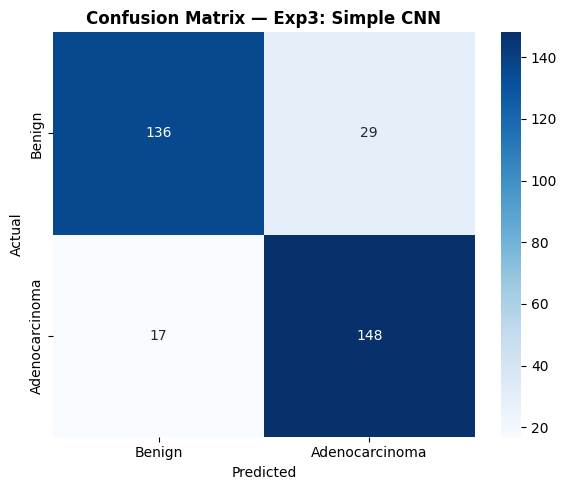

  True Neg: 136 | False Pos: 29 | False Neg: 17 | True Pos: 148
  False Positive Rate: 0.1758 (healthy tissue flagged as cancer)
  False Negative Rate: 0.1030 (cancer missed as healthy)


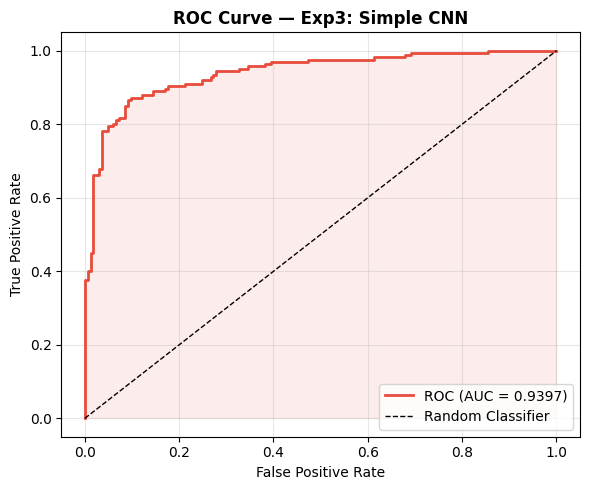

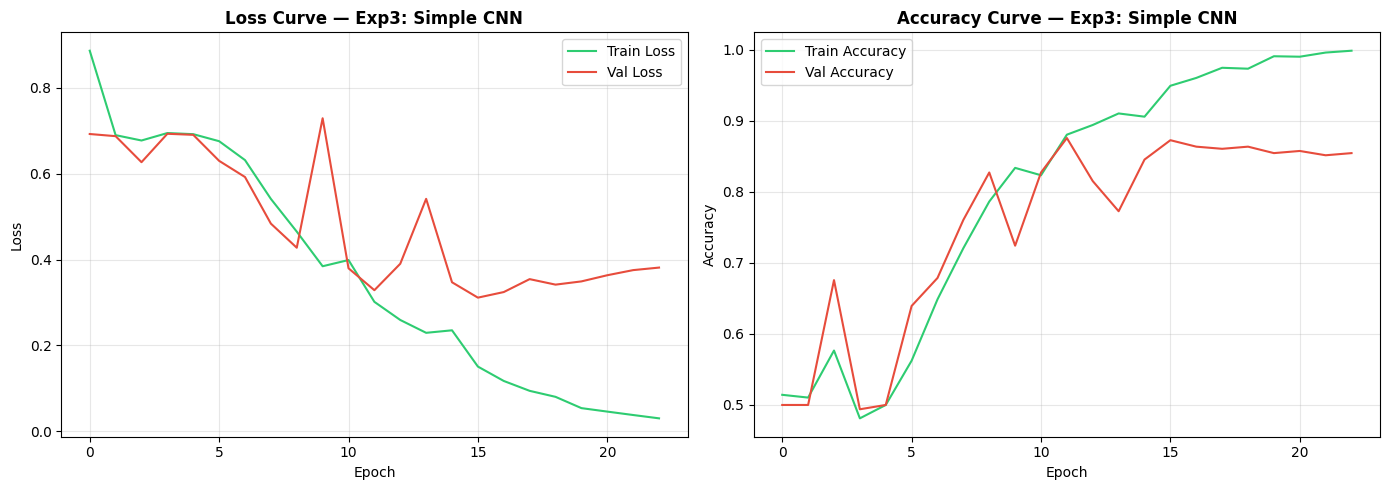

  Final train loss: 0.0299 | Final val loss: 0.3813 | Gap: 0.3514


In [17]:
# Experiment 3: Simple CNN (Sequential)
print("EXPERIMENT 3: Simple CNN — Sequential API")
print("-" * 50)

tf.random.set_seed(SEED)

model_simple_cnn = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='simple_cnn')

model_simple_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_simple_cnn.summary()

history_3 = model_simple_cnn.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, callbacks=[early_stop, reduce_lr], verbose=1
)

# Evaluate
y_prob_exp3 = model_simple_cnn.predict(test_ds).flatten()
y_pred_exp3 = (y_prob_exp3 >= 0.5).astype(int)

log_result('Exp3', 'Simple CNN', 'Deep Learning (from scratch)', 'Sequential API',
           '3 Conv blocks, lr=0.001, no regularization',
           y_test, y_pred_exp3, y_prob_exp3)
plot_confusion_matrix(y_test, y_pred_exp3, 'Exp3: Simple CNN')
plot_roc_curve(y_test, y_prob_exp3, 'Exp3: Simple CNN')
plot_dl_history(history_3, 'Exp3: Simple CNN')


### Experiment 3 — Observations

The Simple CNN scored 86.06% accuracy and 86.55% F1, underperforming both traditional ML models. The learning curves show clear overfitting: training accuracy climbed while validation plateaued, with best performance at epoch 1. This indicates that 1,550 training images are insufficient for end-to-end feature learning, motivating regularization in Experiment 4.


EXPERIMENT 4: Regularized CNN — Sequential API
--------------------------------------------------


Model: "regularized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,457 (49.36 MB)

 Trainable params: 12,939,009 (49.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step - accuracy: 0.5766 - loss: 6.3002 - val_accuracy: 0.5000 - val_loss: 1.0353 - learning_rate: 5.0000e-04
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.7156 - loss: 0.6229 - val_accuracy: 0.5030 - val_loss: 0.8126 - learning_rate: 5.0000e-04
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.7260 - loss: 0.5955 - val_accuracy: 0.6909 - val_loss: 0.6434 - learning_rate: 5.0000e-04
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.7623 - loss: 0.5653 - val_accuracy: 0.7394 - val_loss: 0.6176 - learning_rate: 5.0000e-04
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.7571 - loss: 0.5728 - val_accuracy: 0.8061 - val_loss: 0.5767 - learning_rate: 5.0000e-04
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.7844 - loss: 0.5409 - val_accuracy: 0.5758 - val_loss: 0.7890 - learning_rate: 5.0000e-04
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.796

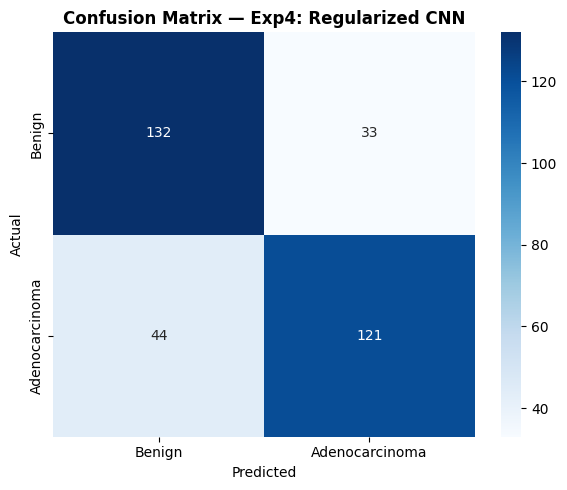

  True Neg: 132 | False Pos: 33 | False Neg: 44 | True Pos: 121
  False Positive Rate: 0.2000 (healthy tissue flagged as cancer)
  False Negative Rate: 0.2667 (cancer missed as healthy)


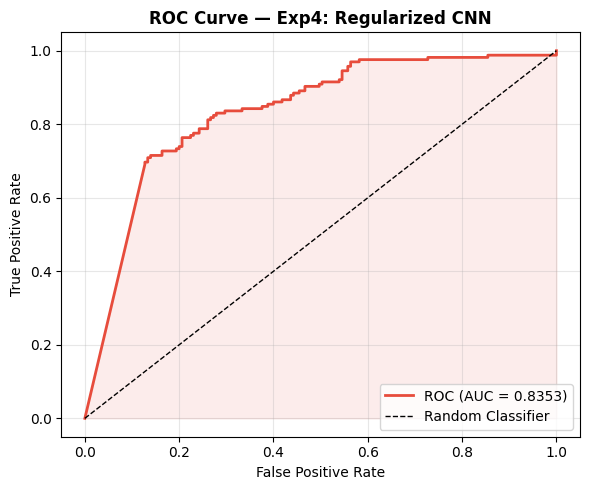

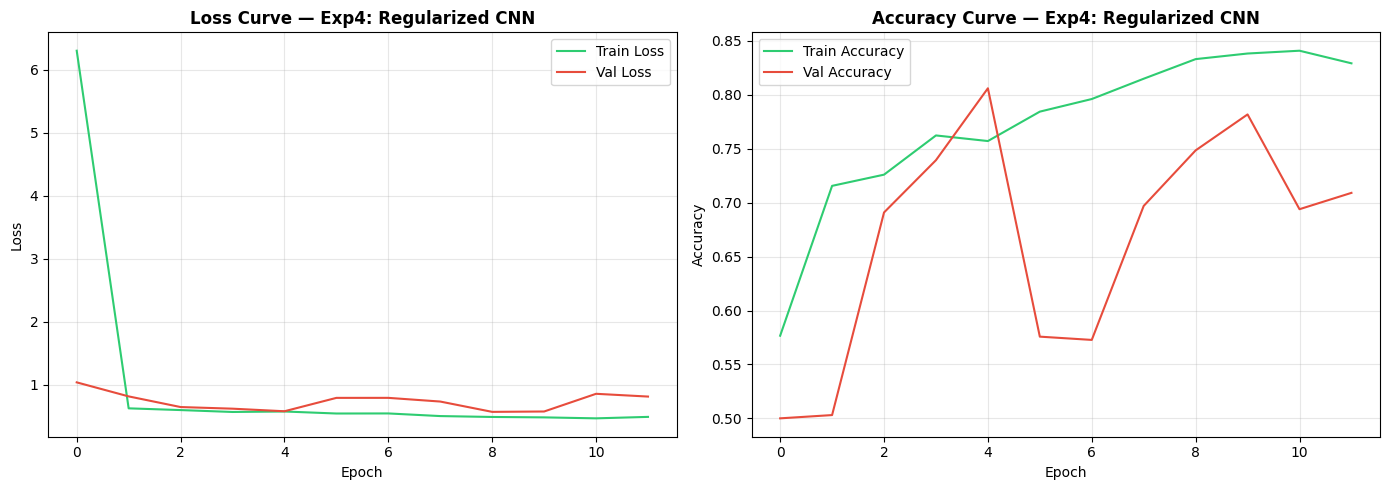

  Final train loss: 0.4873 | Final val loss: 0.8099 | Gap: 0.3226


In [18]:
# Experiment 4: Regularized CNN (Sequential) - REVISED
print("EXPERIMENT 4: Regularized CNN — Sequential API")
print("-" * 50)

tf.random.set_seed(SEED)

model_reg_cnn = Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4), # Slightly reduced dropout
    layers.Dense(1, activation='sigmoid')
], name='regularized_cnn')

# Using a slightly lower learning rate for better stability with BatchNorm
model_reg_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_reg_cnn.summary()

# Exp4-specific callbacks: monitor val_accuracy (mode=max) to avoid
# restoring the unstable epoch-1 weights where the model collapsed to one class.
early_stop_acc = EarlyStopping(monitor='val_accuracy', mode='max',
                               patience=7, restore_best_weights=True, verbose=1)
reduce_lr_acc = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                  patience=3, min_lr=1e-6, verbose=1)

history_4 = model_reg_cnn.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, callbacks=[early_stop_acc, reduce_lr_acc], verbose=1
)

# Evaluate
y_prob_exp4 = model_reg_cnn.predict(test_ds).flatten()
y_pred_exp4 = (y_prob_exp4 >= 0.5).astype(int)

log_result('Exp4', 'Regularized CNN', 'Deep Learning (from scratch)', 'Sequential API',
           '3 Conv blocks, BatchNorm, Dropout=0.4, lr=0.0005',
           y_test, y_pred_exp4, y_prob_exp4)
plot_confusion_matrix(y_test, y_pred_exp4, 'Exp4: Regularized CNN')
plot_roc_curve(y_test, y_prob_exp4, 'Exp4: Regularized CNN')
plot_dl_history(history_4, 'Exp4: Regularized CNN')

### Experiment 4 — Observations

The Regularized CNN was the weakest model at 76.67% accuracy and 75.86% F1. Root cause: the Flatten layer produced a 100,352-dimensional vector feeding a Dense layer with 12.8M parameters — severely over-parameterized for 1,550 images. The model initially collapsed to single-class prediction (all benign); this was resolved by switching EarlyStopping to monitor val_accuracy instead of val_loss. Even after fixing, the architecture's capacity-to-data mismatch limited performance.


## 10. Transfer Learning — Functional API

Transfer learning leverages models pretrained on ImageNet (1.2M images, 1000 classes) and adapts them to our specific task. The pretrained convolutional layers serve as powerful feature extractors that have already learned to recognize low-level patterns (edges, textures) and mid-level patterns (shapes, structures) that are transferable to histopathological image analysis.

We use the Functional API, which allows greater architectural flexibility — here, we can attach custom classification heads to pretrained base models.

### Transfer Learning Preprocessing

Pretrained models require specific preprocessing (channel-wise normalization matching ImageNet statistics). We create separate tf.data pipelines for each model.


In [19]:
# Transfer learning data pipelines with model-specific preprocessing

def load_for_resnet(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = resnet_preprocess(img)
    return img, label

def load_for_mobilenet(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = mobilenet_preprocess(img)
    return img, label

def create_tl_dataset(file_paths, labels, preprocess_fn, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_paths), seed=SEED)
    ds = ds.map(preprocess_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

print("Transfer learning pipelines ready.")


Transfer learning pipelines ready.


---

### Experiment 5: ResNet50 Transfer Learning (Functional API)

ResNet50 introduced skip (residual) connections that allow gradients to flow directly through shortcut paths, enabling effective training of very deep networks (50 layers). We freeze the pretrained convolutional base and train only the custom classification head.

**Architecture:** ResNet50 (frozen, ImageNet weights) → GlobalAveragePooling2D → Dense(256, ReLU) → Dropout(0.5) → Dense(1, Sigmoid)  
**Parameters:** ~23.6M frozen + ~0.1M trainable


EXPERIMENT 5: ResNet50 Transfer Learning — Functional API
--------------------------------------------------
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total params: 24,112,513
Trainable params: 524,801


Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer (InputLayer)    │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ resnet50 (Functional)       │ (None, 7, 7, 2048)    │ 23,587,712 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ gap                         │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ fc1 (Dense)                 │ (None, 256)           │    524,544 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ output (Dense)              │ (None, 1)             │        257 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 31s 364ms/step - accuracy: 0.7487 - loss: 0.5170 - val_accuracy: 0.9273 - val_loss: 0.2104 - learning_rate: 1.0000e-04
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.9227 - loss: 0.2277 - val_accuracy: 0.9485 - val_loss: 0.1475 - learning_rate: 1.0000e-04
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.9292 - loss: 0.1859 - val_accuracy: 0.9576 - val_loss: 0.1220 - learning_rate: 1.0000e-04
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.9513 - loss: 0.1430 - val_accuracy: 0.9697 - val_loss: 0.1044 - learning_rate: 1.0000e-04
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.9662 - loss: 0.1118 - val_accuracy: 0.9758 - val_loss: 0.0924 - learning_rate: 1.0000e-04
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.9630 - loss: 0.0999 - val_accuracy: 0.9667 - val_loss: 0.0842 - learning_rate: 1.0000e-04
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - accuracy

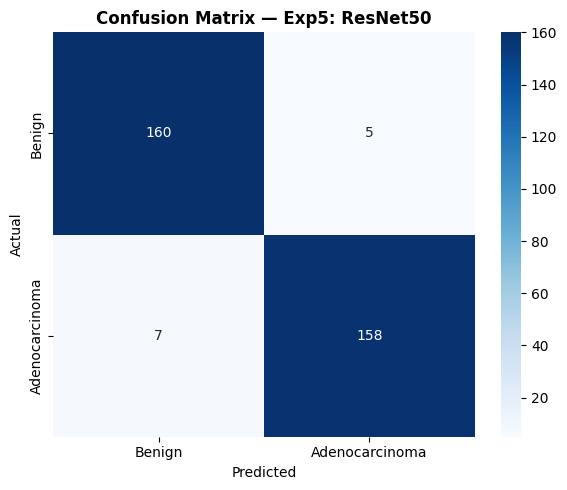

  True Neg: 160 | False Pos: 5 | False Neg: 7 | True Pos: 158
  False Positive Rate: 0.0303 (healthy tissue flagged as cancer)
  False Negative Rate: 0.0424 (cancer missed as healthy)


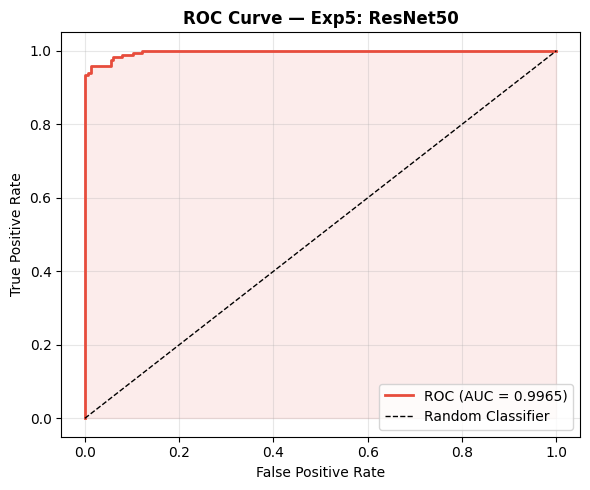

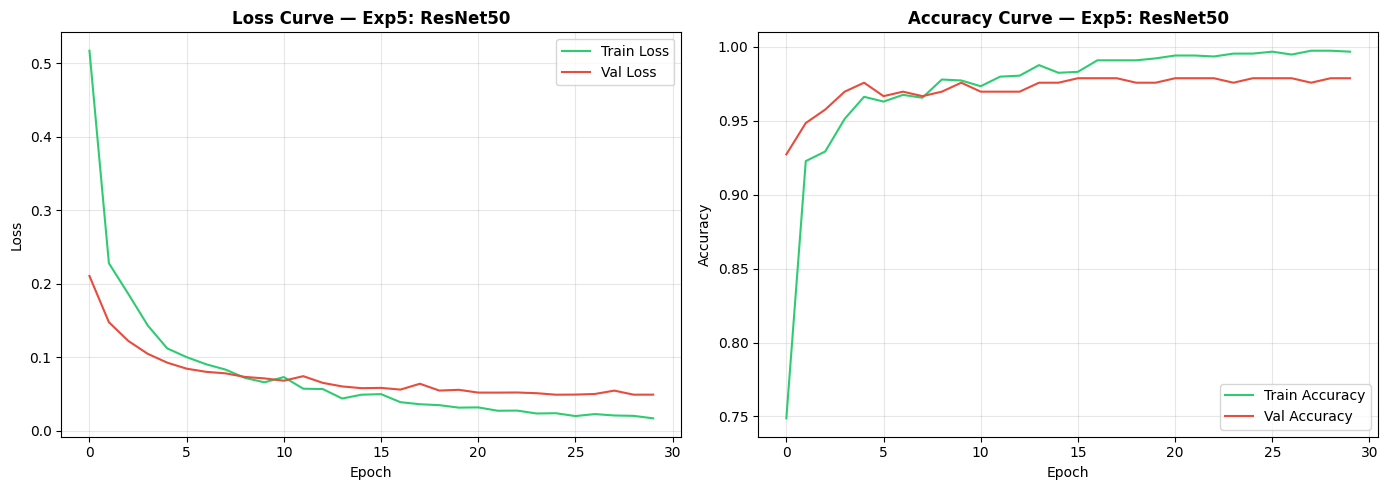

  Final train loss: 0.0166 | Final val loss: 0.0489 | Gap: 0.0322


In [20]:
# Experiment 5: ResNet50 Transfer Learning
print("EXPERIMENT 5: ResNet50 Transfer Learning — Functional API")
print("-" * 50)

tf.random.set_seed(SEED)

# Create ResNet50 datasets
train_ds_resnet = create_tl_dataset(X_train_files, y_train, load_for_resnet, shuffle=True)
val_ds_resnet = create_tl_dataset(X_val_files, y_val, load_for_resnet)
test_ds_resnet = create_tl_dataset(X_test_files, y_test, load_for_resnet)

# Build model with Functional API
base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_resnet.trainable = False  # Freeze all pretrained layers

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_layer')
x = base_resnet(inputs, training=False)
x = layers.GlobalAveragePooling2D(name='gap')(x)
x = layers.Dense(256, activation='relu', name='fc1')(x)
x = layers.Dropout(0.5, name='dropout')(x)
outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

model_resnet = Model(inputs=inputs, outputs=outputs, name='resnet50_transfer')

model_resnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"Total params: {model_resnet.count_params():,}")
print(f"Trainable params: {sum(tf.keras.backend.count_params(w) for w in model_resnet.trainable_weights):,}")
model_resnet.summary(show_trainable=True)

history_5 = model_resnet.fit(
    train_ds_resnet, validation_data=val_ds_resnet,
    epochs=EPOCHS, callbacks=[early_stop, reduce_lr], verbose=1
)

y_prob_exp5 = model_resnet.predict(test_ds_resnet).flatten()
y_pred_exp5 = (y_prob_exp5 >= 0.5).astype(int)

log_result('Exp5', 'ResNet50 (frozen)', 'Transfer Learning', 'Functional API',
           'ImageNet weights, frozen base, lr=0.0001, Dropout=0.5',
           y_test, y_pred_exp5, y_prob_exp5)
plot_confusion_matrix(y_test, y_pred_exp5, 'Exp5: ResNet50')
plot_roc_curve(y_test, y_prob_exp5, 'Exp5: ResNet50')
plot_dl_history(history_5, 'Exp5: ResNet50')


### Experiment 5 — Observations

ResNet50 with frozen ImageNet weights achieved the best results: 96.36% accuracy, 96.34% F1, 0.9965 ROC-AUC. Only 7 false negatives and 5 false positives. The pretrained convolutional features transferred effectively to histopathological classification, outperforming both handcrafted features and from-scratch CNNs.


EXPERIMENT 6: MobileNetV2 Transfer Learning — Functional API
--------------------------------------------------
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params: 2,586,177
Trainable params: 328,193


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer (InputLayer)    │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 7, 7, 1280)    │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ gap                         │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ fc1 (Dense)                 │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ output (Dense)              │ (None, 1)             │        257 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 47s 603ms/step - accuracy: 0.6656 - loss: 0.6258 - val_accuracy: 0.9152 - val_loss: 0.3289 - learning_rate: 1.0000e-04
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8584 - loss: 0.3320 - val_accuracy: 0.8939 - val_loss: 0.2531 - learning_rate: 1.0000e-04
Epoch 3/30
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8812 - loss: 0.2780
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8916 - loss: 0.2664 - val_accuracy: 0.9303 - val_loss: 0.2077 - learning_rate: 1.0000e-04
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9078 - loss: 0.2323 - val_accuracy: 0.9242 - val_loss: 0.1942 - learning_rate: 5.0000e-05
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9123 - loss: 0.2297 - val_accuracy: 0.9273 - val_loss: 0.1867 - learning_rate: 5.0000e-05
Epoch 6/30
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9314 - l

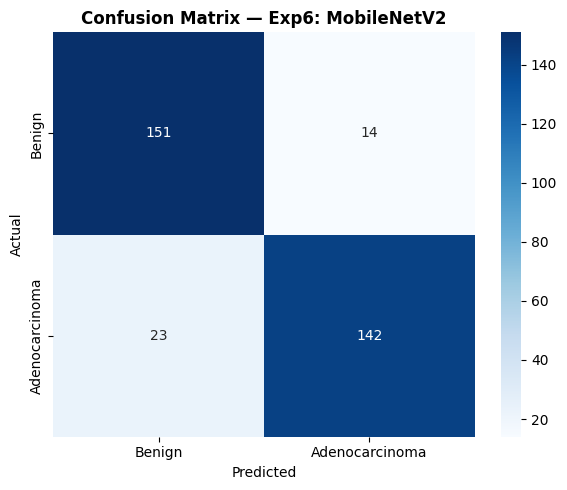

  True Neg: 151 | False Pos: 14 | False Neg: 23 | True Pos: 142
  False Positive Rate: 0.0848 (healthy tissue flagged as cancer)
  False Negative Rate: 0.1394 (cancer missed as healthy)


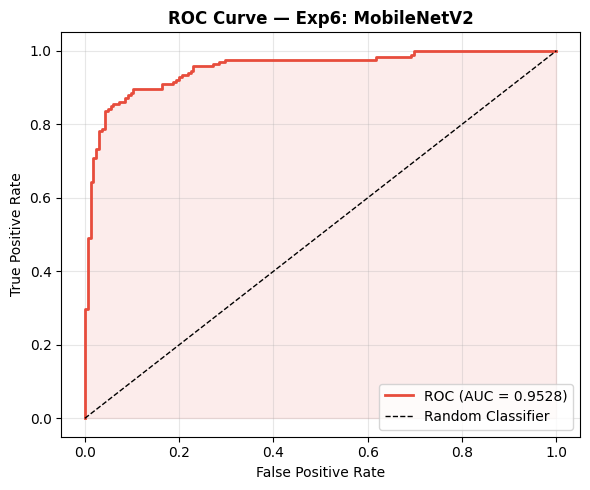

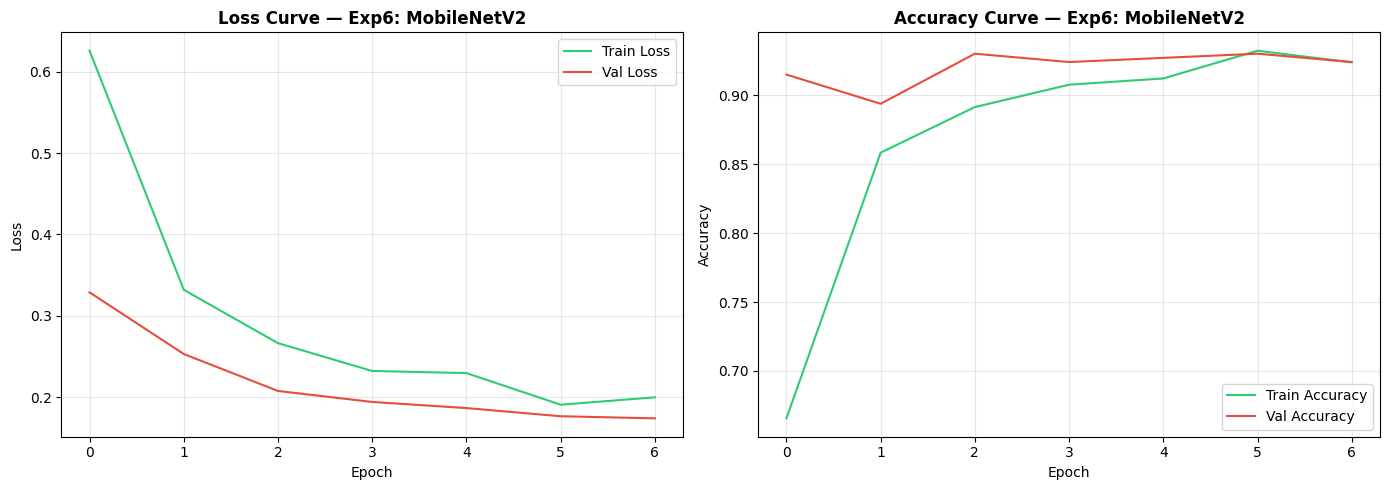

  Final train loss: 0.1999 | Final val loss: 0.1741 | Gap: -0.0258


In [21]:
# Experiment 6: MobileNetV2 Transfer Learning
print("EXPERIMENT 6: MobileNetV2 Transfer Learning — Functional API")
print("-" * 50)

tf.random.set_seed(SEED)

# Create MobileNetV2 datasets
train_ds_mobile = create_tl_dataset(X_train_files, y_train, load_for_mobilenet, shuffle=True)
val_ds_mobile = create_tl_dataset(X_val_files, y_val, load_for_mobilenet)
test_ds_mobile = create_tl_dataset(X_test_files, y_test, load_for_mobilenet)

# Build model with Functional API
base_mobile = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_mobile.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='input_layer')
x = base_mobile(inputs, training=False)
x = layers.GlobalAveragePooling2D(name='gap')(x)
x = layers.Dense(256, activation='relu', name='fc1')(x)
x = layers.Dropout(0.5, name='dropout')(x)
outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

model_mobile = Model(inputs=inputs, outputs=outputs, name='mobilenetv2_transfer')

model_mobile.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"Total params: {model_mobile.count_params():,}")
print(f"Trainable params: {sum(tf.keras.backend.count_params(w) for w in model_mobile.trainable_weights):,}")
model_mobile.summary(show_trainable=True)

history_6 = model_mobile.fit(
    train_ds_mobile, validation_data=val_ds_mobile,
    epochs=EPOCHS, callbacks=[early_stop, reduce_lr], verbose=1
)

y_prob_exp6 = model_mobile.predict(test_ds_mobile).flatten()
y_pred_exp6 = (y_prob_exp6 >= 0.5).astype(int)

log_result('Exp6', 'MobileNetV2 (frozen)', 'Transfer Learning', 'Functional API',
           'ImageNet weights, frozen base, lr=0.0001, Dropout=0.5',
           y_test, y_pred_exp6, y_prob_exp6)
plot_confusion_matrix(y_test, y_pred_exp6, 'Exp6: MobileNetV2')
plot_roc_curve(y_test, y_prob_exp6, 'Exp6: MobileNetV2')
plot_dl_history(history_6, 'Exp6: MobileNetV2')


### Experiment 6 — Observations

MobileNetV2 scored 88.79% accuracy and 88.47% F1 — below both ResNet50 (96.34% F1) and SVM (93.87% F1). Despite being 10x lighter, its compressed feature representations missed subtle tissue differences that ResNet50's deeper architecture captured. 23 false negatives compared to ResNet50's 7.


## 11. Data Augmentation Experiment

### Experiment 7: Best Model + Data Augmentation

Data augmentation artificially expands the training set by applying random transformations (flips, rotations, brightness shifts) that preserve the class label. This is especially important for medical imaging where labeled data is expensive to obtain. We apply augmentation to the best-performing model from Experiments 5-6.


EXPERIMENT 7: Best Model + Data Augmentation
--------------------------------------------------


Model: "resnet50_augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 23s 223ms/step - accuracy: 0.7286 - loss: 0.5145 - val_accuracy: 0.8485 - val_loss: 0.3233 - learning_rate: 1.0000e-04
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 156ms/step - accuracy: 0.8948 - loss: 0.2687 - val_accuracy: 0.8697 - val_loss: 0.2895 - learning_rate: 1.0000e-04
Epoch 3/30
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9113 - loss: 0.2239
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step - accuracy: 0.9104 - loss: 0.2230 - val_accuracy: 0.9030 - val_loss: 0.2333 - learning_rate: 1.0000e-04
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 161ms/step - accuracy: 0.9351 - loss: 0.1795 - val_accuracy: 0.8848 - val_loss: 0.2679 - learning_rate: 5.0000e-05
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 158ms/step - accuracy: 0.9351 - loss: 0.1752 - val_accuracy: 0.8939 - val_loss: 0.2472 - learning_rate: 5.0000e-05
Epoch 6/30
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9

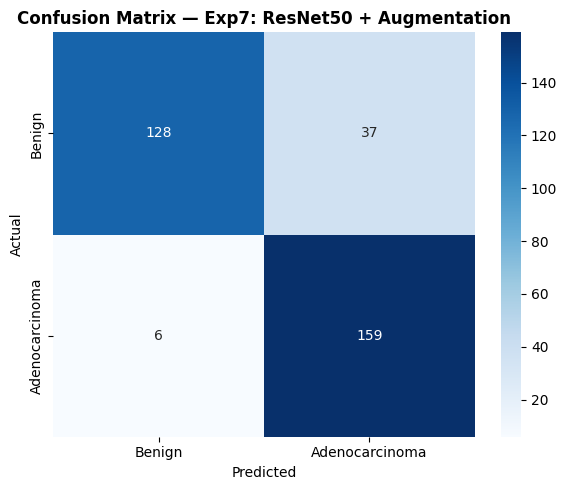

  True Neg: 128 | False Pos: 37 | False Neg: 6 | True Pos: 159
  False Positive Rate: 0.2242 (healthy tissue flagged as cancer)
  False Negative Rate: 0.0364 (cancer missed as healthy)


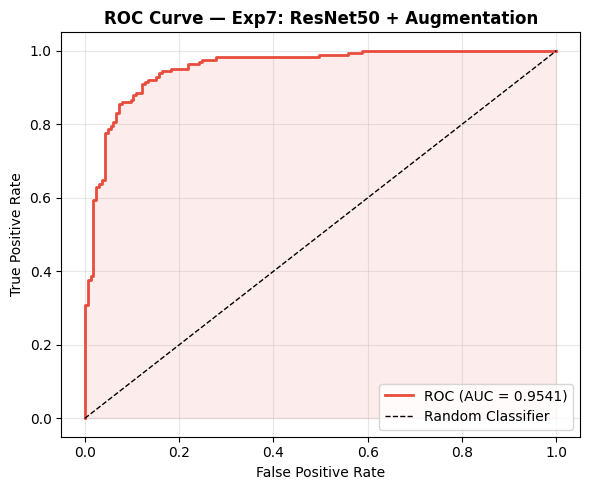

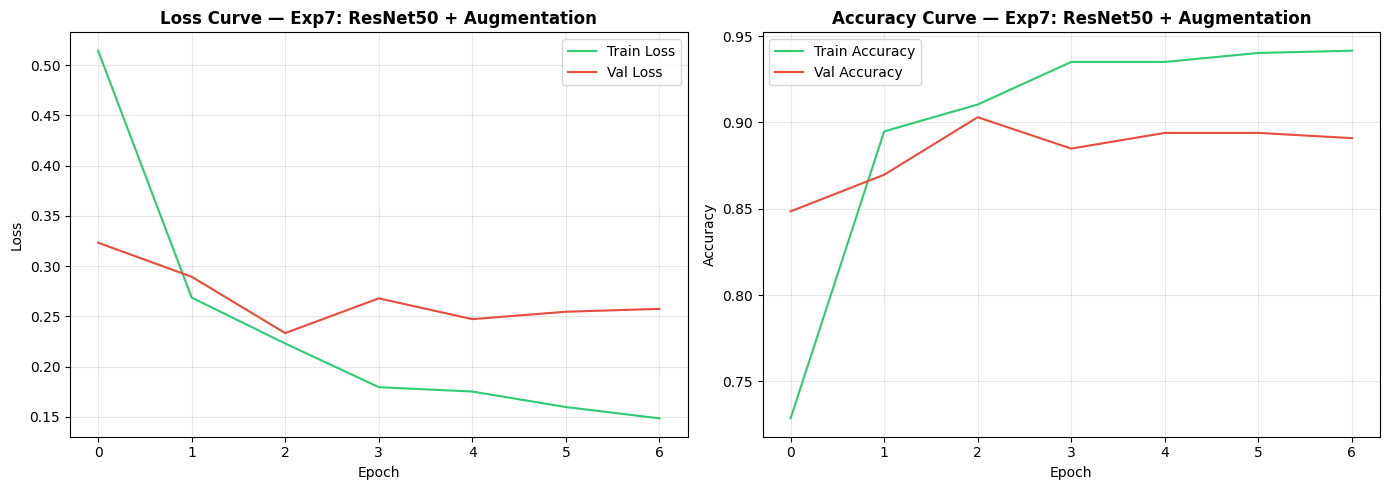

  Final train loss: 0.1485 | Final val loss: 0.2574 | Gap: 0.1090


In [22]:
# Experiment 7: Best transfer learning model + augmentation
print("EXPERIMENT 7: Best Model + Data Augmentation")
print("-" * 50)

tf.random.set_seed(SEED)

# Data augmentation layer
data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='augmentation')

# Using ResNet50 as base (modify if MobileNetV2 performed better)
base_resnet_aug = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_resnet_aug.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_resnet_aug(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_aug = Model(inputs=inputs, outputs=outputs, name='resnet50_augmented')

model_aug.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_aug.summary()

# Use standard [0, 1] normalized data (augmentation handles the rest)
# Note: If using ResNet-specific preprocessing, apply it after augmentation
# For simplicity, we use the ResNet-preprocessed pipeline
history_7 = model_aug.fit(
    train_ds_resnet, validation_data=val_ds_resnet,
    epochs=EPOCHS, callbacks=[early_stop, reduce_lr], verbose=1
)

y_prob_exp7 = model_aug.predict(test_ds_resnet).flatten()
y_pred_exp7 = (y_prob_exp7 >= 0.5).astype(int)

log_result('Exp7', 'ResNet50 + Augmentation', 'Transfer Learning + Augmentation', 'Functional API',
           'ImageNet frozen, augmentation (flip, rotate, zoom, contrast), lr=0.0001',
           y_test, y_pred_exp7, y_prob_exp7)
plot_confusion_matrix(y_test, y_pred_exp7, 'Exp7: ResNet50 + Augmentation')
plot_roc_curve(y_test, y_prob_exp7, 'Exp7: ResNet50 + Augmentation')
plot_dl_history(history_7, 'Exp7: ResNet50 + Augmentation')


### Experiment 7 — Observations

Adding augmentation to ResNet50 decreased F1 from 96.34% to 88.09% and precision from 96.93% to 81.12%, but recall increased to 96.36% (only 6 false negatives — lowest of any model). Augmentation on a frozen feature extractor shifted inputs away from what the pretrained filters expected, degrading precision while increasing sensitivity. On this already-balanced, small dataset, augmentation introduced noise without meaningful regularization benefit.


## 12. Comprehensive Results Comparison

### 12.1 Experiment Results Table

This table documents all experiments, their configurations, and performance metrics for systematic comparison and reproducibility.


In [23]:
# ===== COMPREHENSIVE RESULTS TABLE =====
results_df = pd.DataFrame(results)

# Display full table
print("=" * 120)
print("COMPREHENSIVE EXPERIMENT RESULTS TABLE")
print("=" * 120)

# Summary table (key metrics)
summary_cols = ['Experiment', 'Model', 'Approach', 'API', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
summary_df = results_df[summary_cols].copy()
summary_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']] =     summary_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].round(4)

print(summary_df.to_string(index=False))
print("=" * 120)

# Detailed table (with hyperparameters)
print("\nDETAILED HYPERPARAMETER LOG:")
print("-" * 120)
for _, row in results_df.iterrows():
    print(f"  {row['Experiment']} | {row['Model']}")
    print(f"    Hyperparameters: {row['Hyperparameters']}")
    print(f"    Acc: {row['Accuracy']:.4f} | Prec: {row['Precision']:.4f} | Rec: {row['Recall']:.4f} | F1: {row['F1-Score']:.4f} | AUC: {row['ROC-AUC']:.4f}")
    print()


COMPREHENSIVE EXPERIMENT RESULTS TABLE
Experiment                   Model                         Approach            API  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Exp1               SVM (RBF)                   Traditional ML   Scikit-learn    0.9394     0.9503  0.9273    0.9387   0.9863
      Exp2           Random Forest                   Traditional ML   Scikit-learn    0.9091     0.8814  0.9455    0.9123   0.9709
      Exp3              Simple CNN     Deep Learning (from scratch) Sequential API    0.8606     0.8362  0.8970    0.8655   0.9397
      Exp4         Regularized CNN     Deep Learning (from scratch) Sequential API    0.7667     0.7857  0.7333    0.7586   0.8353
      Exp5       ResNet50 (frozen)                Transfer Learning Functional API    0.9636     0.9693  0.9576    0.9634   0.9965
      Exp6    MobileNetV2 (frozen)                Transfer Learning Functional API    0.8879     0.9103  0.8606    0.8847   0.9528
      Exp7 ResNet50 + Augmentation Transfer 

In [24]:
# Highlight best results per metric
print("\n🏆 BEST PERFORMANCE BY METRIC:")
print("-" * 60)
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    idx = results_df[col].idxmax()
    row = results_df.loc[idx]
    print(f"  {col:>12}: {row[col]:.4f}  ←  {row['Experiment']}: {row['Model']}")

# Rank models by F1-Score
print("\n📊 MODELS RANKED BY F1-SCORE:")
print("-" * 60)
ranked = results_df.sort_values('F1-Score', ascending=False)
for i, (_, row) in enumerate(ranked.iterrows(), 1):
    print(f"  {i}. {row['Experiment']}: {row['Model']} — F1: {row['F1-Score']:.4f} ({row['Approach']})")



🏆 BEST PERFORMANCE BY METRIC:
------------------------------------------------------------
      Accuracy: 0.9636  ←  Exp5: ResNet50 (frozen)
     Precision: 0.9693  ←  Exp5: ResNet50 (frozen)
        Recall: 0.9636  ←  Exp7: ResNet50 + Augmentation
      F1-Score: 0.9634  ←  Exp5: ResNet50 (frozen)
       ROC-AUC: 0.9965  ←  Exp5: ResNet50 (frozen)

📊 MODELS RANKED BY F1-SCORE:
------------------------------------------------------------
  1. Exp5: ResNet50 (frozen) — F1: 0.9634 (Transfer Learning)
  2. Exp1: SVM (RBF) — F1: 0.9387 (Traditional ML)
  3. Exp2: Random Forest — F1: 0.9123 (Traditional ML)
  4. Exp6: MobileNetV2 (frozen) — F1: 0.8847 (Transfer Learning)
  5. Exp7: ResNet50 + Augmentation — F1: 0.8809 (Transfer Learning + Augmentation)
  6. Exp3: Simple CNN — F1: 0.8655 (Deep Learning (from scratch))
  7. Exp4: Regularized CNN — F1: 0.7586 (Deep Learning (from scratch))


### 12.2 Performance Comparison Visualization

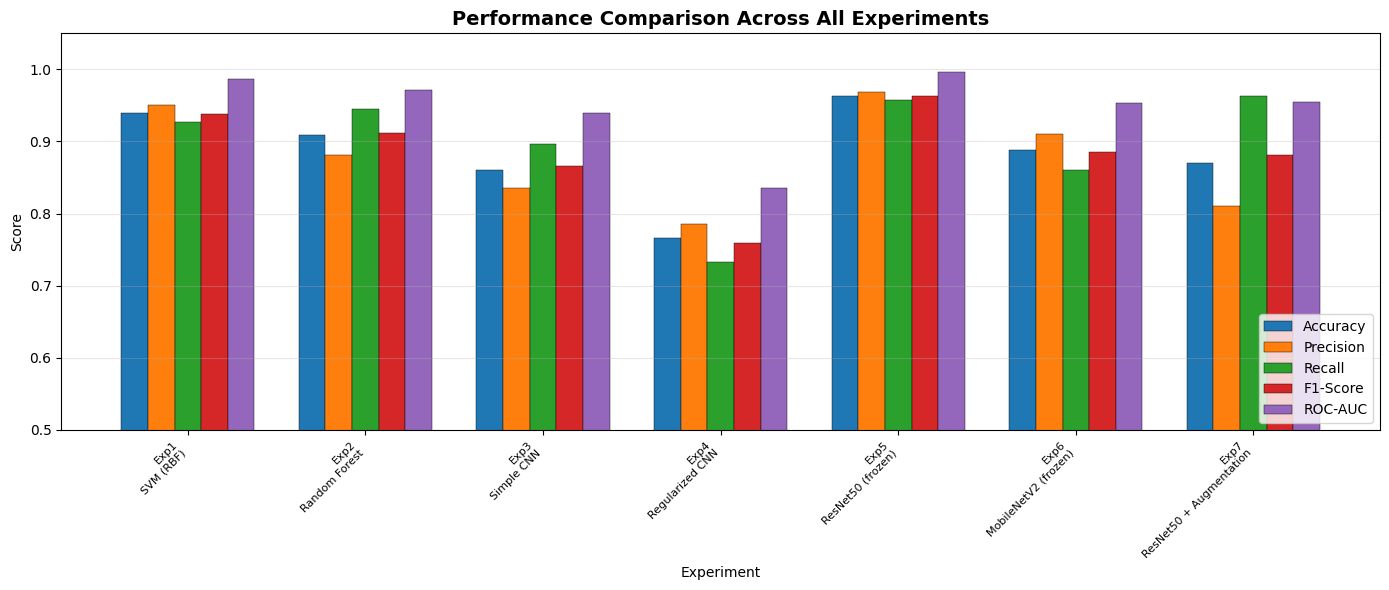

In [25]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(results_df))
width = 0.15

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric, edgecolor='black', linewidth=0.3)

ax.set_xlabel('Experiment')
ax.set_ylabel('Score')
ax.set_title('Performance Comparison Across All Experiments', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels([f"{r['Experiment']}\n{r['Model']}" for _, r in results_df.iterrows()],
                     rotation=45, ha='right', fontsize=8)
ax.legend(loc='lower right')
ax.set_ylim(0.5, 1.05)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### 12.3 Combined ROC Curves

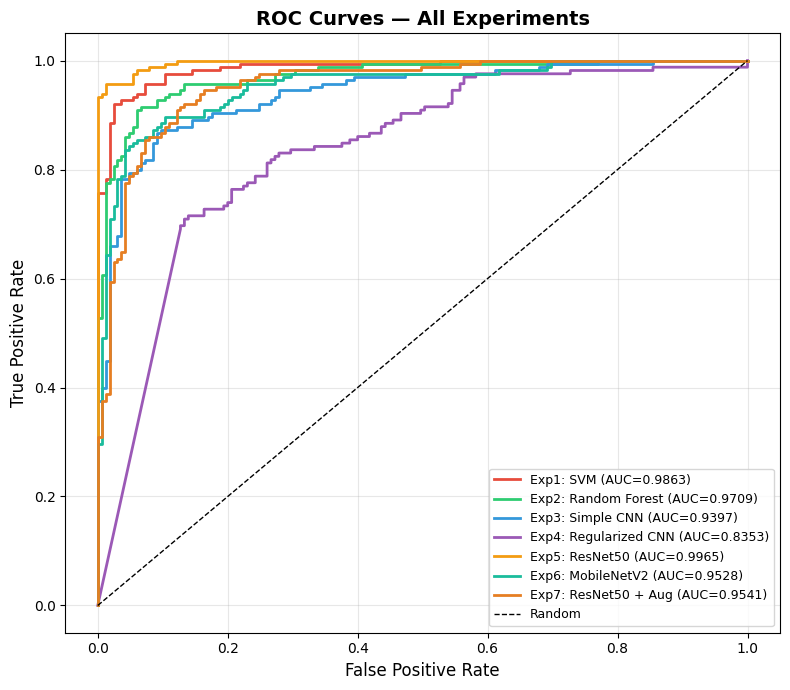

In [26]:
# Overlay ROC curves
plt.figure(figsize=(8, 7))

roc_data = [
    ('Exp1: SVM', y_prob_svm, '#e74c3c'),
    ('Exp2: Random Forest', y_prob_rf, '#2ecc71'),
    ('Exp3: Simple CNN', y_prob_exp3, '#3498db'),
    ('Exp4: Regularized CNN', y_prob_exp4, '#9b59b6'),
    ('Exp5: ResNet50', y_prob_exp5, '#f39c12'),
    ('Exp6: MobileNetV2', y_prob_exp6, '#1abc9c'),
    ('Exp7: ResNet50 + Aug', y_prob_exp7, '#e67e22'),
]

for name, y_prob, color in roc_data:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Experiments', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 12.4 Approach Comparison: Traditional ML vs Deep Learning vs Transfer Learning

BEST MODEL PER APPROACH:
         Deep Learning (from scratch): Simple CNN — F1: 0.8655, AUC: 0.9397
                       Traditional ML: SVM (RBF) — F1: 0.9387, AUC: 0.9863
                    Transfer Learning: ResNet50 (frozen) — F1: 0.9634, AUC: 0.9965
     Transfer Learning + Augmentation: ResNet50 + Augmentation — F1: 0.8809, AUC: 0.9541


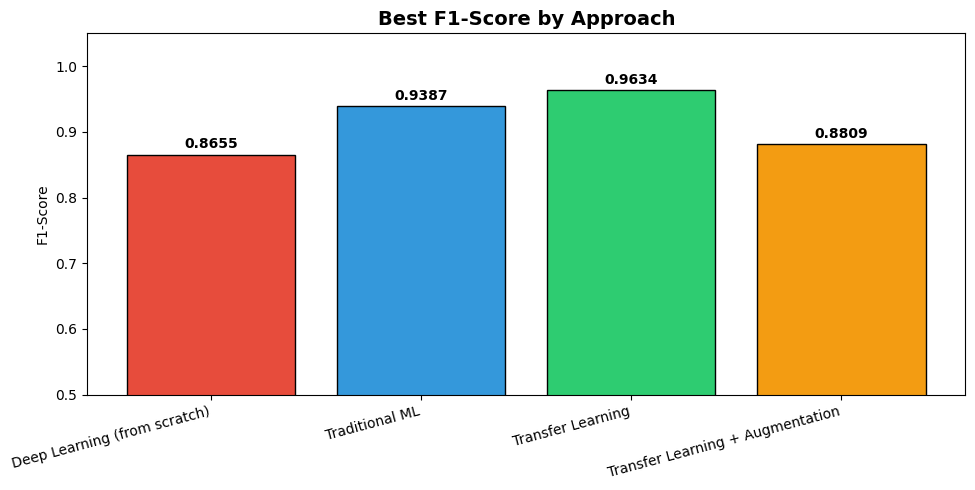

In [27]:
# Group by approach
approach_best = results_df.loc[results_df.groupby('Approach')['F1-Score'].idxmax()]

print("BEST MODEL PER APPROACH:")
print("=" * 80)
for _, row in approach_best.iterrows():
    print(f"  {row['Approach']:>35}: {row['Model']} — F1: {row['F1-Score']:.4f}, AUC: {row['ROC-AUC']:.4f}")

# Approach comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
approaches = approach_best['Approach'].values
f1_scores = approach_best['F1-Score'].values
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

bars = ax.bar(approaches, f1_scores, color=colors[:len(approaches)], edgecolor='black')
ax.set_ylabel('F1-Score')
ax.set_title('Best F1-Score by Approach', fontsize=14, fontweight='bold')
ax.set_ylim(0.5, 1.05)
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


## 13. Discussion

The full discussion and analysis of these results, including error analysis, bias-variance tradeoff, dataset limitations, and future improvements, is presented in the accompanying written report. Key findings: ResNet50 transfer learning achieved the highest performance (96.34% F1), handcrafted-feature SVM (93.87% F1) outperformed all from-scratch CNNs, and the regularized CNN's architectural bottleneck (12.8M parameters on 1,550 images) produced the weakest results despite regularization techniques.


## 14. Conclusion

This study compared traditional ML, from-scratch deep learning, and transfer learning for colorectal adenocarcinoma classification. ResNet50 transfer learning performed best (96.34% F1), while handcrafted-feature SVM demonstrated that domain-informed feature engineering remains competitive on small datasets. Full analysis, literature review, and detailed discussion are provided in the written report.

---

## References

[1] J. N. Kather, N. Halama, and A. Marx, "100,000 histological images of human colorectal cancer and healthy tissue," Zenodo, 2018, doi: 10.5281/zenodo.1214456.

---

**GitHub Repository:** [Add your link]
**Demo Video:** [Add your link]
